# 06 — Crime-Weather Analysis

**Objective.** Determine whether Chicago crime activity is associated with
weather conditions, whether that association differs by season / weekday
/ location, and whether weather adds value beyond calendar and historical
crime patterns.

**Period.** 2021-01-01 → 2025-12-31.

**Data.** Crime daily aggregate (`community_area × date`) + NOAA weather
(`date`, station `USW00094846`).

**Analytical unit.** `community_area × date` for spatial questions;
citywide daily total for weather ↔ overall-crime questions (weather has
one value per day, not per area).

**Research questions**
1. How does daily crime vary with temperature, precipitation, snow, wind?
2. Are rainy/snowy/extreme-temperature days different from other days?
3. Are relationships linear or nonlinear?
4. Do relationships differ by season, weekday/weekend, crime category, area?
5. Does weather add value beyond calendar/historical-crime patterns?
6. Which findings are robust enough for the model dataset (07)?

**Rule.** This is EDA, not causal inference. Findings are reported as
*associated with*, *correlated with*, *higher/lower under* — never
*causes*.


## 02 — Environment & Imports

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

from src import config
from src.features.temporal_features import create_date_features

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

RANDOM_STATE = config.RANDOM_STATE

CRIME_DAILY_PATH = config.DATA_INTERIM / "crime_daily.parquet"
WEATHER_CLEANED_PATH = config.DATA_INTERIM / "weather_cleaned.parquet"
MERGED_OUT_PATH = config.DATA_INTERIM / "crime_weather_daily.parquet"

FIG_DIR = config.OUTPUTS_DIR / "figures"
TABLE_DIR = config.OUTPUTS_DIR / "tables"
for d in [FIG_DIR / "weather", FIG_DIR / "crime_weather", FIG_DIR / "statistical", TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

ALPHA = 0.05  # significance threshold used throughout

## 03 — Load & Validate Prepared Data

Reuses existing pipeline outputs — no preprocessing logic is duplicated
here. Fails fast if a required input is missing (no silent fallback).

In [2]:
for path, producer in [(CRIME_DAILY_PATH, "03_spatiotemporal_feature_engineering"),
                        (WEATHER_CLEANED_PATH, "05_weather_analysis")]:
    if not path.exists():
        raise FileNotFoundError(f"{path} not found. Run {producer}.ipynb first.")

crime_daily = pd.read_parquet(CRIME_DAILY_PATH)
weather = pd.read_parquet(WEATHER_CLEANED_PATH)
crime_daily["date"] = pd.to_datetime(crime_daily["date"])
weather["date"] = pd.to_datetime(weather["date"])
print(f"crime_daily: {crime_daily.shape}    weather: {weather.shape}")

crime_daily: (140602, 22)    weather: (1826, 15)


In [3]:
REQUIRED_CRIME_COLS = ["community_area", "date", "crime_count", "violent_crime_count",
                       "property_crime_count", "drug_crime_count", "arrest_rate", "domestic_rate"]
REQUIRED_WEATHER_COLS = ["date", "station", "TMAX", "TMIN", "PRCP", "SNOW", "AWND", "avg_temp"]

missing_crime_cols = [c for c in REQUIRED_CRIME_COLS if c not in crime_daily.columns]
missing_weather_cols = [c for c in REQUIRED_WEATHER_COLS if c not in weather.columns]
if missing_crime_cols or missing_weather_cols:
    raise KeyError(f"missing crime cols: {missing_crime_cols}; missing weather cols: {missing_weather_cols}")
print("Required columns present in both frames.")

Required columns present in both frames.


### Crime — validation

In [4]:
crime_validation = {
    "shape": crime_daily.shape,
    "date_min": crime_daily["date"].min(),
    "date_max": crime_daily["date"].max(),
    "n_unique_dates": crime_daily["date"].nunique(),
    "n_community_areas": crime_daily["community_area"].nunique(),
    "dtypes_ok": crime_daily["date"].dtype.kind == "M",
    "n_missing_total": int(crime_daily[REQUIRED_CRIME_COLS].isna().sum().sum()),
    "n_duplicate_rows": int(crime_daily.duplicated(subset=["community_area", "date"]).sum()),
    "n_negative_crime_count": int((crime_daily["crime_count"] < 0).sum()),
}
crime_validation

{'shape': (140602, 22),
 'date_min': Timestamp('2021-01-01 00:00:00'),
 'date_max': Timestamp('2025-12-31 00:00:00'),
 'n_unique_dates': 1826,
 'n_community_areas': 77,
 'dtypes_ok': True,
 'n_missing_total': 0,
 'n_duplicate_rows': 0,
 'n_negative_crime_count': 0}

In [5]:
expected_dates = pd.date_range(config.START_DATE, config.END_DATE, freq="D")
expected_grid = len(expected_dates) * crime_daily["community_area"].nunique()
assert crime_daily.shape[0] == expected_grid, (
    f"crime_daily is not a full community_area x date grid: "
    f"{crime_daily.shape[0]} rows, expected {expected_grid}"
)
assert crime_validation["n_missing_total"] == 0, "unexpected missing values in required crime columns"
assert crime_validation["n_duplicate_rows"] == 0, "duplicate community_area x date rows in crime_daily"
assert crime_validation["n_negative_crime_count"] == 0, "negative crime_count is impossible -- investigate upstream"
assert crime_validation["date_min"] == pd.Timestamp(config.START_DATE)
assert crime_validation["date_max"] == pd.Timestamp(config.END_DATE)
print("Crime validation passed: full grid, in-scope dates, no missing/duplicate/negative values.")

Crime validation passed: full grid, in-scope dates, no missing/duplicate/negative values.


### Weather — validation

In [6]:
weather_validation = {
    "shape": weather.shape,
    "date_min": weather["date"].min(),
    "date_max": weather["date"].max(),
    "n_unique_dates": weather["date"].nunique(),
    "stations": sorted(weather["station"].unique().tolist()),
    "numeric_dtypes_ok": all(pd.api.types.is_numeric_dtype(weather[c]) for c in ["TMAX", "TMIN", "PRCP", "SNOW", "AWND"]),
    "n_missing_total": int(weather[REQUIRED_WEATHER_COLS].isna().sum().sum()),
    "n_duplicate_dates": int(weather["date"].duplicated().sum()),
}
weather_validation

{'shape': (1826, 15),
 'date_min': Timestamp('2021-01-01 00:00:00'),
 'date_max': Timestamp('2025-12-31 00:00:00'),
 'n_unique_dates': 1826,
 'stations': ['USW00094846'],
 'numeric_dtypes_ok': True,
 'n_missing_total': 0,
 'n_duplicate_dates': 0}

In [7]:
assert weather_validation["n_unique_dates"] == len(weather), "weather has more than one row for some date(s)"
assert weather_validation["stations"] == [config.NOAA_STATION_ID], "unexpected station id(s) in weather data"
assert weather_validation["numeric_dtypes_ok"], "weather numeric columns are not numeric -- rerun 05's cleaning step"
assert weather_validation["n_duplicate_dates"] == 0
assert weather_validation["date_min"] == pd.Timestamp(config.START_DATE)
assert weather_validation["date_max"] == pd.Timestamp(config.END_DATE)
print("Weather validation passed: single station, one row per date, numeric dtypes, in-scope dates.")

Weather validation passed: single station, one row per date, numeric dtypes, in-scope dates.


## 04 — Integration Audit

**Join design**

```
crime: community_area x date  +  weather: date  ->  community_area x date + weather
```

Merge key is `date` — weather is city-level, one reading per day, broadcast
across all 77 community areas that day.

In [8]:
audit = {
    "crime_date_min": crime_daily["date"].min(), "crime_date_max": crime_daily["date"].max(),
    "weather_date_min": weather["date"].min(), "weather_date_max": weather["date"].max(),
    "n_crime_dates": crime_daily["date"].nunique(), "n_weather_dates": weather["date"].nunique(),
    "n_overlapping_dates": len(set(crime_daily["date"]) & set(weather["date"])),
    "n_crime_dates_without_weather": len(set(crime_daily["date"]) - set(weather["date"])),
    "n_weather_dates_without_crime": len(set(weather["date"]) - set(crime_daily["date"])),
    "n_duplicate_weather_dates": int(weather["date"].duplicated().sum()),
}
pd.Series(audit)

crime_date_min                   2021-01-01 00:00:00
crime_date_max                   2025-12-31 00:00:00
weather_date_min                 2021-01-01 00:00:00
weather_date_max                 2025-12-31 00:00:00
n_crime_dates                                   1826
n_weather_dates                                 1826
n_overlapping_dates                             1826
n_crime_dates_without_weather                      0
n_weather_dates_without_crime                      0
n_duplicate_weather_dates                          0
dtype: object

In [9]:
assert audit["n_duplicate_weather_dates"] == 0, "weather must have at most one row per date before merging"

date_check = crime_daily[["date"]].drop_duplicates().merge(
    weather[["date"]], on="date", how="outer", indicator=True
)
match_summary = date_check["_merge"].value_counts()
match_pct = (match_summary.get("both", 0) / len(date_check)) * 100
print(match_summary)
print(f"date match rate: {match_pct:.2f}%")
assert match_pct == 100.0, "not all crime dates have a weather match -- resolve before merging (do not proceed silently)"


_merge
both          1826
left_only        0
right_only       0
Name: count, dtype: int64
date match rate: 100.00%


In [10]:
weather_cols = [c for c in weather.columns if c not in ("date", "station")]
merged = crime_daily.merge(weather[["date"] + weather_cols], on="date", how="left", validate="many_to_one", indicator=True)

row_check = merged["_merge"].value_counts()
print(row_check)
assert (merged["_merge"] == "both").all(), "some crime rows failed to match a weather row"
merged = merged.drop(columns="_merge")
assert len(merged) == len(crime_daily), "row count changed during merge"
assert merged[weather_cols].isna().sum().sum() == 0, "unexpected nulls introduced by merge"
print(f"merged: {merged.shape} -- 100% matched, row count unchanged")

_merge
both          140602
left_only          0
right_only         0
Name: count, dtype: int64
merged: (140602, 35) -- 100% matched, row count unchanged


In [11]:
merged.to_parquet(MERGED_OUT_PATH, index=False)
print(f"saved {len(merged)} rows -> {MERGED_OUT_PATH}")

saved 140602 rows -> C:\Users\Tarankit\Documents\Code\spatial-temporal-crime-trajectory-analytics\data\interim\crime_weather_daily.parquet


**Limitation.** All 77 community areas share one O'Hare reading per day.
This is citywide-approximate weather, not neighborhood-level weather —
carried forward as a stated limitation, not treated as spatial precision.

## 05 — Combined Dataset Overview

| Column | Type | Meaning | Source |
|---|---|---|---|
| `date` | datetime | Calendar date | Crime |
| `community_area` | categorical | Chicago community area (1-77) | Crime |
| `crime_count` | numeric | Daily incidents, area-level | Crime |
| `violent_crime_count` | numeric | Daily violent incidents | Crime |
| `property_crime_count` | numeric | Daily property incidents | Crime |
| `drug_crime_count` | numeric | Daily drug incidents | Crime |
| `arrest_rate` | numeric | Share of incidents with arrest | Crime |
| `domestic_rate` | numeric | Share of incidents flagged domestic | Crime |
| `avg_temp` | numeric | (TMAX+TMIN)/2, °F | Weather (derived) |
| `temp_range` | numeric | TMAX-TMIN, °F | Weather (derived) |
| `PRCP` | numeric | Precipitation, in | Weather |
| `SNOW` | numeric | Snowfall, in | Weather |
| `AWND` | numeric | Average wind speed | Weather |
| `is_rain` / `is_snow` / `is_heavy_rain` / `is_heavy_snow` / `is_extreme_heat` / `is_extreme_cold` | bool | Documented threshold flags | Weather (derived) |


In [12]:
numeric_cols_all = merged.select_dtypes(include=np.number).columns.tolist()
categorical_cols_all = merged.select_dtypes(exclude=[np.number, "datetime64[ns]", "bool"]).columns.tolist()

overview = {
    "shape": merged.shape,
    "date_range": (merged["date"].min(), merged["date"].max()),
    "n_unique_dates": merged["date"].nunique(),
    "n_community_areas": merged["community_area"].nunique(),
    "n_numeric_cols": len(numeric_cols_all),
    "n_categorical_cols": len(categorical_cols_all),
    "total_missingness_pct": round(merged.isna().mean().mean() * 100, 3),
}
overview

{'shape': (140602, 35),
 'date_range': (Timestamp('2021-01-01 00:00:00'),
  Timestamp('2025-12-31 00:00:00')),
 'n_unique_dates': 1826,
 'n_community_areas': 77,
 'n_numeric_cols': 28,
 'n_categorical_cols': 0,
 'total_missingness_pct': np.float64(0.239)}

## 06 — Individual Variable Profiling

Profiled before cross-analysis, per blueprint requirement.

In [13]:
citywide = (
    merged.groupby("date")
    .agg(
        crime_count=("crime_count", "sum"),
        violent_crime_count=("violent_crime_count", "sum"),
        property_crime_count=("property_crime_count", "sum"),
        drug_crime_count=("drug_crime_count", "sum"),
        avg_temp=("avg_temp", "first"), temp_range=("temp_range", "first"),
        TMAX=("TMAX", "first"), TMIN=("TMIN", "first"),
        PRCP=("PRCP", "first"), SNOW=("SNOW", "first"), AWND=("AWND", "first"),
        is_rain=("is_rain", "first"), is_snow=("is_snow", "first"),
        is_heavy_rain=("is_heavy_rain", "first"), is_heavy_snow=("is_heavy_snow", "first"),
        is_extreme_heat=("is_extreme_heat", "first"), is_extreme_cold=("is_extreme_cold", "first"),
    )
    .reset_index()
)
citywide["other_crime_count"] = (
    citywide["crime_count"] - citywide["violent_crime_count"]
    - citywide["property_crime_count"] - citywide["drug_crime_count"]
).clip(lower=0)
# NOTE: 'other' = FRAUD + OTHER + unclassified per CRIME_CATEGORY_MAP -- the
# daily aggregate (Phase 5) only tracks violent/property/drug subtotals
# separately, so this remainder is a documented limitation, not an omission.

citywide = create_date_features(citywide, date_col="date")  # reused from src/, not reimplemented
assert len(citywide) == weather["date"].nunique()
citywide.head()

,date,crime_count,violent_crime_count,property_crime_count,drug_crime_count,avg_temp,temp_range,TMAX,TMIN,PRCP,SNOW,AWND,is_rain,is_snow,is_heavy_rain,is_heavy_snow,is_extreme_heat,is_extreme_cold,other_crime_count,year,month,day,day_of_week,week_of_year,quarter,season,is_weekend
0,2021-01-01,863,235,222,12,27.0,16,35,19,0.38,1.3,11.86,True,True,False,False,False,True,394,2021,1,1,4,53,1,Winter,False
1,2021-01-02,450,135,166,20,31.5,7,35,28,0.00,0.0,6.26,False,False,False,False,False,False,129,2021,1,2,5,53,1,Winter,True
2,2021-01-03,516,167,202,24,29.5,7,33,26,0.03,0.4,6.93,True,True,False,False,False,False,123,2021,1,3,6,53,1,Winter,True
3,2021-01-04,535,143,191,14,27.0,6,30,24,0.00,0.0,7.83,False,False,False,False,False,False,187,2021,1,4,0,1,1,Winter,False
4,2021-01-05,541,142,211,21,33.0,8,37,29,0.00,0.0,5.59,False,False,False,False,False,False,167,2021,1,5,1,1,1,Winter,False


In [14]:
numeric_profile_cols = ["crime_count", "avg_temp", "TMAX", "TMIN", "PRCP", "SNOW", "AWND"]
profile_rows = []
for col in numeric_profile_cols:
    s = citywide[col]
    profile_rows.append({
        "variable": col, "count": s.count(), "mean": round(s.mean(), 2), "median": round(s.median(), 2),
        "std": round(s.std(), 2), "min": round(s.min(), 2), "Q1": round(s.quantile(0.25), 2),
        "Q3": round(s.quantile(0.75), 2), "max": round(s.max(), 2), "skew": round(stats.skew(s.dropna()), 2),
    })
numeric_profile_df = pd.DataFrame(profile_rows).set_index("variable")
numeric_profile_df

,count,mean,median,std,min,Q1,Q3,max,skew
variable,,,,,,,,,
crime_count,1826,662.68,668.00,94.43,342.00,603.25,725.00,1142.00,-0.15
avg_temp,1826,53.25,54.25,19.52,-4.50,38.00,70.50,87.50,-0.35
TMAX,1826,61.65,64.00,20.86,-1.00,45.00,80.00,100.00,-0.34
TMIN,1826,44.85,45.00,18.69,-10.00,32.00,62.00,80.00,-0.36
PRCP,1826,0.09,0.00,0.25,0.00,0.00,0.03,3.35,4.87
SNOW,1826,0.09,0.00,0.51,0.00,0.00,0.00,8.40,8.75
AWND,1826,9.47,9.17,3.38,2.24,6.93,11.41,27.96,0.64


`crime_count` and `PRCP`/`SNOW` are expected to show the largest skew (right-skewed, zero-inflated) — median/quantiles are the reliable summary for those, not the mean.

In [15]:
categorical_profile_cols = ["season", "day_of_week", "is_weekend"]
for col in categorical_profile_cols:
    vc = citywide[col].value_counts()
    pct = (vc / len(citywide) * 100).round(1)
    print(f"\n-- {col} --")
    print(pd.DataFrame({"count": vc, "pct": pct}))


-- season --
        count   pct
season             
Spring    460  25.2
Summer    460  25.2
Fall      455  24.9
Winter    451  24.7

-- day_of_week --
             count   pct
day_of_week             
4              261  14.3
5              261  14.3
6              261  14.3
0              261  14.3
1              261  14.3
2              261  14.3
3              260  14.2

-- is_weekend --
            count   pct
is_weekend             
False        1304  71.4
True          522  28.6


In [16]:
area_freq = crime_daily["community_area"].value_counts()
print(f"community_area: {area_freq.nunique()} unique values, {area_freq.min()}-{area_freq.max()} rows each (expect {crime_daily['date'].nunique()} each on a full grid)")

category_totals = citywide[["violent_crime_count", "property_crime_count", "drug_crime_count", "other_crime_count"]].sum()
category_pct = (category_totals / category_totals.sum() * 100).round(1)
pd.DataFrame({"total_incidents": category_totals, "pct_of_total": category_pct})

community_area: 1 unique values, 1826-1826 rows each (expect 1826 each on a full grid)


,total_incidents,pct_of_total
violent_crime_count,378080,31.2
property_crime_count,571341,47.2
drug_crime_count,29069,2.4
other_crime_count,231569,19.1


**Note on the cell above.** `area_freq.nunique()` reports how many *distinct row-counts* exist across areas (1 — every area has exactly 1,826 rows), not the number of areas. The area count itself is confirmed elsewhere: 77 unique `community_area` values (Section 03 validation, Section 05 overview).

## 07 — Crime-Weather Univariate Analysis

Weather variables profiled independently before pairing with crime.
(Deeper weather-only EDA — decomposition, ACF, change-points — already
covered in notebook 05; this section stays scoped to what the combined
analysis needs.)

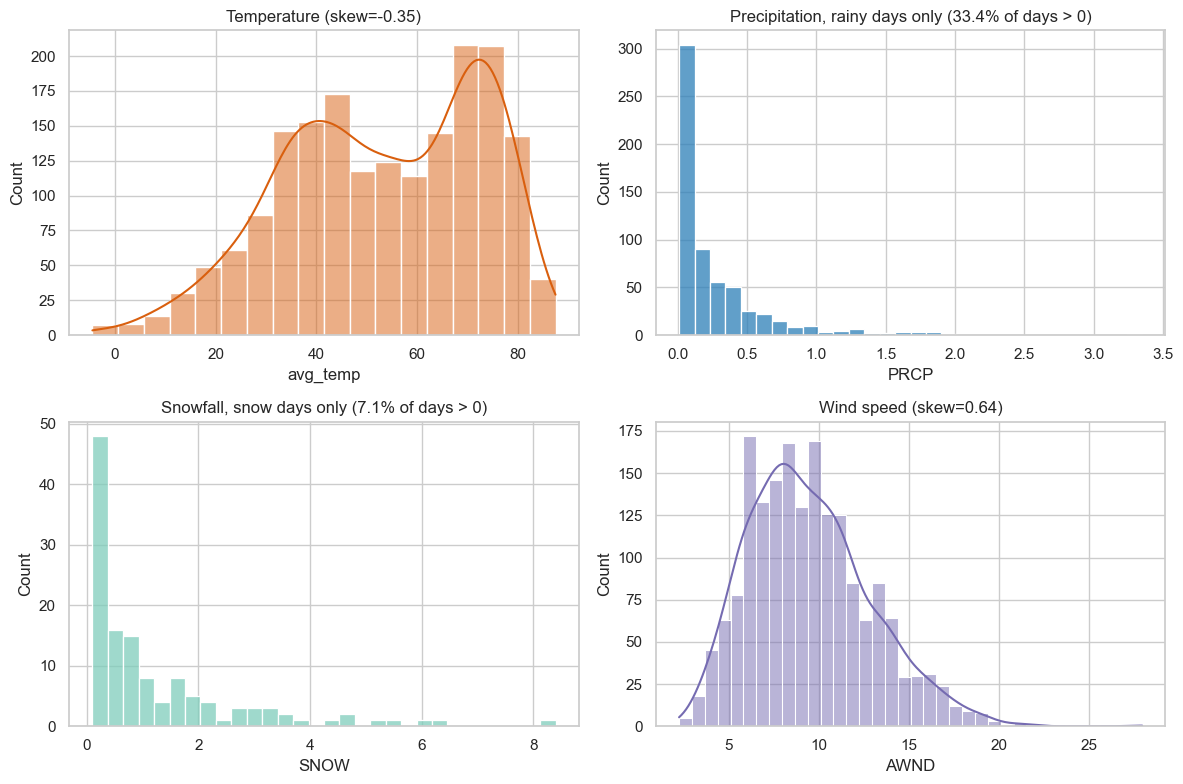

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(citywide["avg_temp"], kde=True, ax=axes[0, 0], color="#d95f0e")
axes[0, 0].set_title(f"Temperature (skew={stats.skew(citywide['avg_temp']):.2f})")

rain_day_pct = (citywide["PRCP"] > 0).mean() * 100
sns.histplot(citywide.loc[citywide["PRCP"] > 0, "PRCP"], bins=30, ax=axes[0, 1], color="#2c7fb8")
axes[0, 1].set_title(f"Precipitation, rainy days only ({rain_day_pct:.1f}% of days > 0)")

snow_day_pct = (citywide["SNOW"] > 0).mean() * 100
sns.histplot(citywide.loc[citywide["SNOW"] > 0, "SNOW"], bins=30, ax=axes[1, 0], color="#7fcdbb")
axes[1, 0].set_title(f"Snowfall, snow days only ({snow_day_pct:.1f}% of days > 0)")

sns.histplot(citywide["AWND"], kde=True, ax=axes[1, 1], color="#756bb1")
axes[1, 1].set_title(f"Wind speed (skew={stats.skew(citywide['AWND']):.2f})")

plt.tight_layout()
fig.savefig(FIG_DIR / "weather" / "weather_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

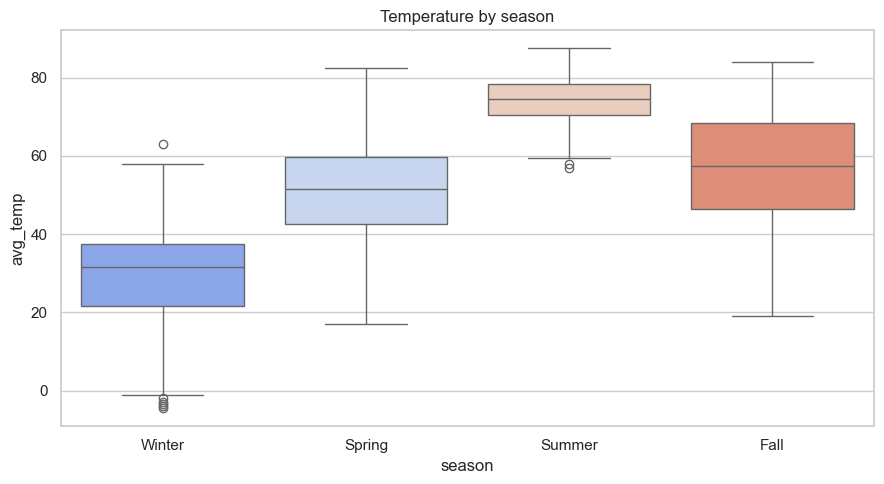

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=citywide, x="season", y="avg_temp", order=["Winter", "Spring", "Summer", "Fall"],
            hue="season", legend=False, palette="coolwarm", ax=ax)
ax.set_title("Temperature by season")
plt.tight_layout()
plt.show()

**Zero-inflation note (blueprint requirement).** `PRCP` and `SNOW` are
mostly zero — `is_rain`/`is_snow` flags and group comparisons (Section 10),
not histograms of the raw series, are the primary tool for these two
variables.

## 08 — Bivariate Relationships (Numeric × Numeric)

Crime is right-skewed (Section 06) → **Spearman is the primary
correlation measure**; Pearson is reported alongside for comparability but
is not the basis for conclusions when the two disagree.

In [19]:
weather_num_cols = ["avg_temp", "temp_range", "PRCP", "SNOW", "AWND"]
correlation_rows = []
for wcol in weather_num_cols:
    pear_r, pear_p = stats.pearsonr(citywide[wcol], citywide["crime_count"])
    spear_r, spear_p = stats.spearmanr(citywide[wcol], citywide["crime_count"])
    correlation_rows.append({
        "weather_var": wcol, "crime_var": "crime_count",
        "pearson_r": round(pear_r, 3), "pearson_p": pear_p,
        "spearman_r": round(spear_r, 3), "spearman_p": spear_p,
        "primary_method": "spearman",
    })
correlation_results_df = pd.DataFrame(correlation_rows)
correlation_results_df

,weather_var,crime_var,pearson_r,pearson_p,spearman_r,spearman_p,primary_method
0,avg_temp,crime_count,0.569,1.939875e-157,0.552,5.297301e-146,spearman
1,temp_range,crime_count,0.191,1.698960e-16,0.228,6.343489e-23,spearman
2,PRCP,crime_count,-0.043,6.452990e-02,-0.112,1.445959e-06,spearman
3,SNOW,crime_count,-0.250,1.833746e-27,-0.270,8.239950e-32,spearman
4,AWND,crime_count,-0.183,3.613217e-15,-0.169,4.047222e-13,spearman


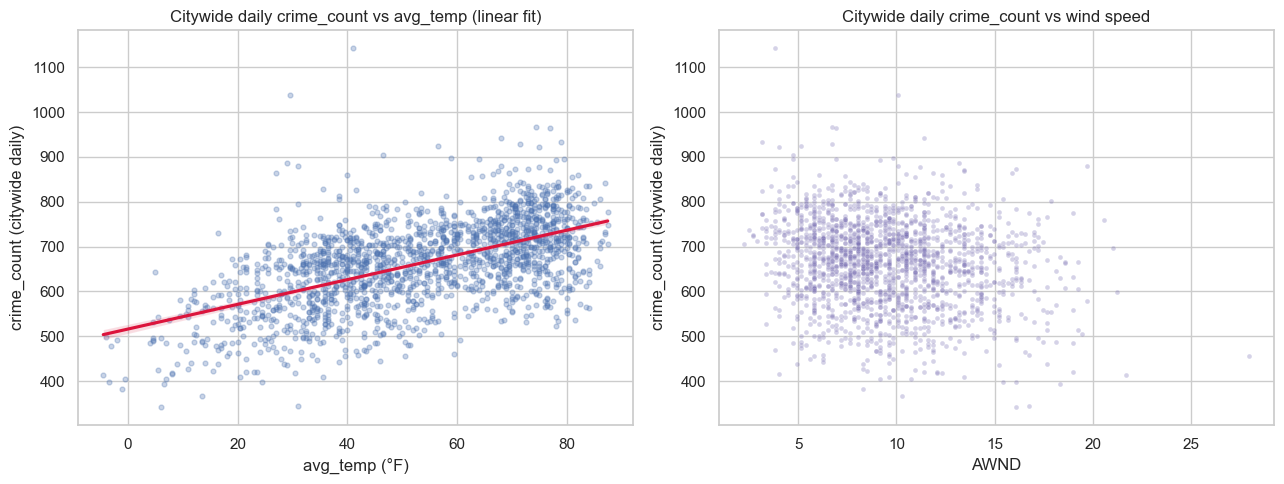

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.regplot(data=citywide, x="avg_temp", y="crime_count", ax=axes[0],
            scatter_kws={"alpha": 0.3, "s": 12}, line_kws={"color": "crimson"})
axes[0].set_title("Citywide daily crime_count vs avg_temp (linear fit)")
axes[0].set_xlabel("avg_temp (°F)"); axes[0].set_ylabel("crime_count (citywide daily)")

sns.scatterplot(data=citywide, x="AWND", y="crime_count", ax=axes[1], alpha=0.3, s=12, color="#756bb1")
axes[1].set_title("Citywide daily crime_count vs wind speed")
axes[1].set_xlabel("AWND"); axes[1].set_ylabel("crime_count (citywide daily)")
plt.tight_layout()
fig.savefig(FIG_DIR / "crime_weather" / "bivariate_temp_wind.png", dpi=120, bbox_inches="tight")
plt.show()

## 09 — Nonlinear Relationship Analysis

LOWESS is applied to `avg_temp` only — continuous, enough variation, a
plausibly nonlinear (e.g. peak-then-plateau) relationship. It is **not**
applied to `PRCP`/`SNOW`: those are zero-inflated (Section 07), which
breaks LOWESS's assumptions and produces an uninterpretable curve. Rain and
snow are compared as **groups** instead (Section 10).

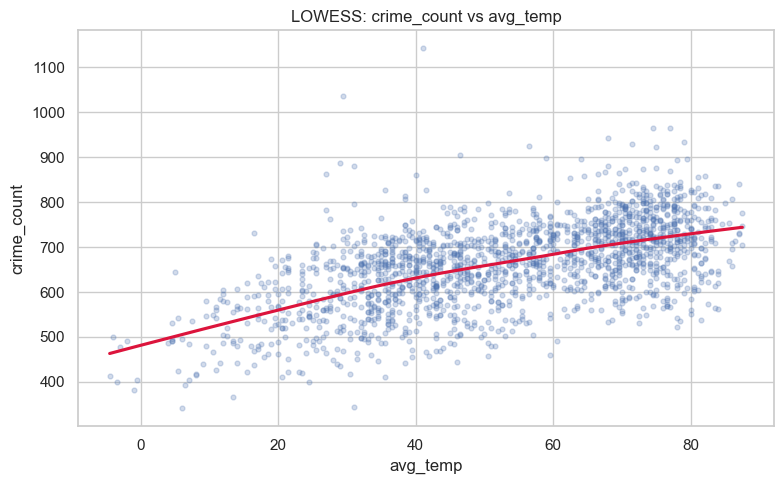

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(data=citywide, x="avg_temp", y="crime_count", lowess=True, ax=ax,
            scatter_kws={"alpha": 0.25, "s": 12}, line_kws={"color": "crimson"})
ax.set_title("LOWESS: crime_count vs avg_temp")
plt.tight_layout()
plt.show()

**Reading.** The LOWESS curve tracks the linear fit closely across most of
the temperature range — the temperature–crime relationship is
**effectively monotonic and near-linear**, not humped or plateaued.
Continuous `avg_temp` is an adequate feature; a temperature-bin variant
adds no obvious benefit here (confirmed again in Section 16).

## 10 — Weather Condition Group Comparisons

Mann-Whitney U throughout (crime is non-normal, Section 06). Effect size =
rank-biserial correlation, not just p-value.

In [22]:
def rank_biserial(x, y):
    n1, n2 = len(x), len(y)
    u_stat, _ = stats.mannwhitneyu(x, y, alternative="two-sided")
    return 2 * u_stat / (n1 * n2) - 1

def group_test(flag_col, value_col="crime_count", df=citywide):
    grp_true = df.loc[df[flag_col], value_col]
    grp_false = df.loc[~df[flag_col], value_col]
    if len(grp_true) < 5:
        return {"flag": flag_col, "n_flagged": len(grp_true), "n_other": len(grp_false),
                "median_flagged": grp_true.median() if len(grp_true) else np.nan,
                "median_other": grp_false.median(), "mean_flagged": grp_true.mean() if len(grp_true) else np.nan,
                "mean_other": grp_false.mean(), "u_stat": np.nan, "p_value": np.nan,
                "rank_biserial": np.nan, "note": "n<5 flagged -- test unreliable"}
    u_stat, p_val = stats.mannwhitneyu(grp_true, grp_false, alternative="two-sided")
    return {"flag": flag_col, "n_flagged": len(grp_true), "n_other": len(grp_false),
            "median_flagged": grp_true.median(), "median_other": grp_false.median(),
            "mean_flagged": round(grp_true.mean(), 3), "mean_other": round(grp_false.mean(), 3),
            "u_stat": u_stat, "p_value": p_val, "rank_biserial": round(rank_biserial(grp_true, grp_false), 3), "note": ""}

weather_group_comparisons_df = pd.DataFrame([
    group_test(f) for f in ["is_rain", "is_snow", "is_heavy_rain", "is_heavy_snow", "is_extreme_heat", "is_extreme_cold"]
])
weather_group_comparisons_df

,flag,n_flagged,n_other,median_flagged,median_other,mean_flagged,mean_other,u_stat,p_value,rank_biserial,note
0,is_rain,609,1217,653.0,676.0,648.483,669.789,319870.0,1.811182e-06,-0.137,
1,is_snow,129,1697,572.0,675.0,563.318,670.236,43184.5,1.676124e-30,-0.605,
2,is_heavy_rain,29,1797,645.0,669.0,650.276,662.883,23431.5,3.514670e-01,-0.101,
3,is_heavy_snow,8,1818,444.0,669.0,441.500,663.656,511.0,5.540720e-06,-0.930,
4,is_extreme_heat,109,1717,728.0,665.0,724.789,658.740,132859.0,1.852658e-13,0.420,
5,is_extreme_cold,188,1638,553.0,679.0,552.979,675.274,48361.5,1.130817e-53,-0.686,


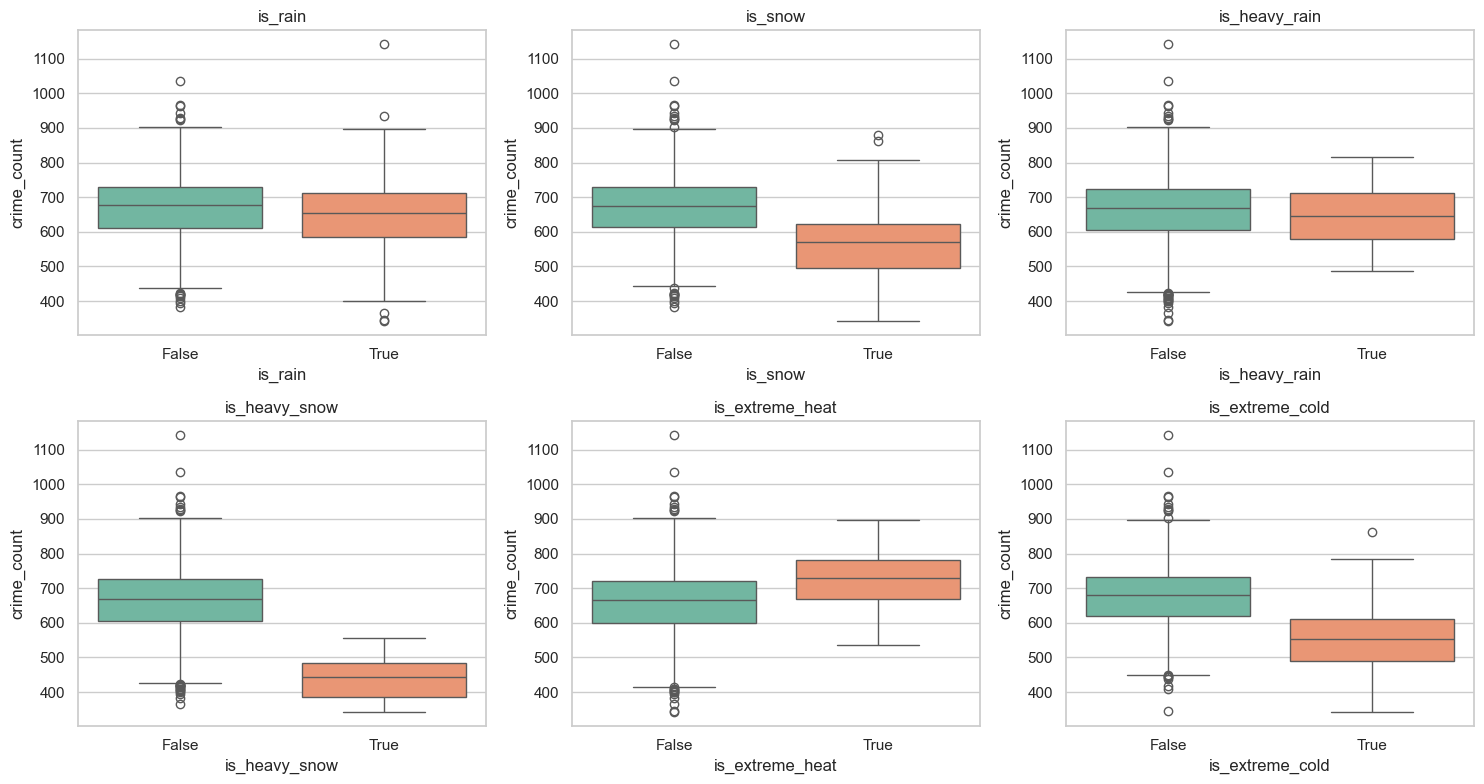

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
flags = ["is_rain", "is_snow", "is_heavy_rain", "is_heavy_snow", "is_extreme_heat", "is_extreme_cold"]
for ax, flag in zip(axes.ravel(), flags):
    sns.boxplot(data=citywide, x=flag, y="crime_count", hue=flag, legend=False, palette="Set2", ax=ax)
    ax.set_title(flag)
plt.tight_layout()
fig.savefig(FIG_DIR / "crime_weather" / "weather_flag_boxplots.png", dpi=120, bbox_inches="tight")
plt.show()

**Effect-size guide.** |rank-biserial| < 0.1 negligible, 0.1-0.3
small, 0.3-0.5 medium, > 0.5 large. Do not read a low-n flag's p-value
(likely `is_heavy_snow`) without its `note` caveat.

## 11 — Temporal Stratification

Weather is seasonal by definition — a raw temperature-crime correlation
can be confounded by season. Compare the overall relationship against the
season-stratified relationship before trusting it.

In [24]:
season_corr_rows = []
for season_name, grp in citywide.groupby("season"):
    r, p = stats.spearmanr(grp["avg_temp"], grp["crime_count"])
    season_corr_rows.append({"season": season_name, "n_days": len(grp), "spearman_r": round(r, 3), "p_value": p})
season_corr_df = pd.DataFrame(season_corr_rows).set_index("season").loc[["Winter", "Spring", "Summer", "Fall"]]
overall_r = correlation_results_df.loc[correlation_results_df["weather_var"] == "avg_temp", "spearman_r"].iloc[0]
print(f"overall (unstratified) spearman r = {overall_r}")
season_corr_df

overall (unstratified) spearman r = 0.552


,n_days,spearman_r,p_value
season,,,
Winter,451,0.548,1.122495e-36
Spring,460,0.404,1.856322e-19
Summer,460,0.083,7.638692e-02
Fall,455,0.428,9.762832e-22


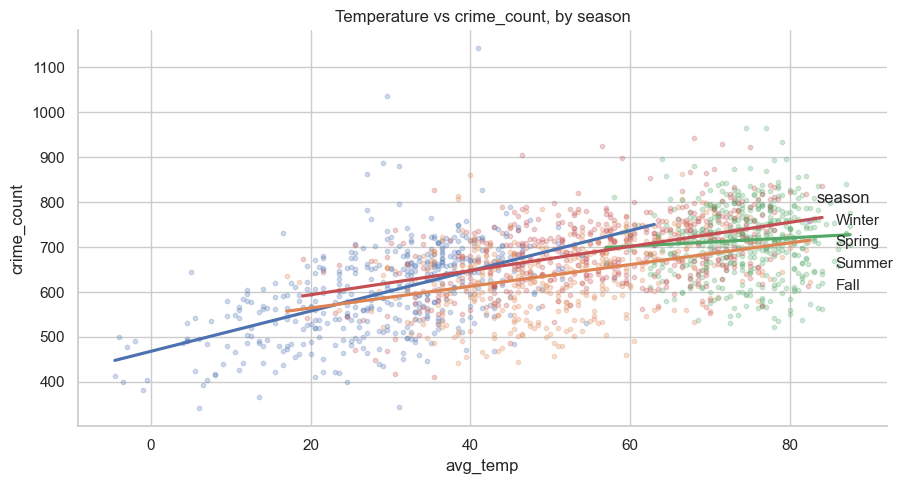

In [25]:
g = sns.lmplot(
    data=citywide, 
    x="avg_temp", 
    y="crime_count", 
    hue="season", 
    hue_order=["Winter", "Spring", "Summer", "Fall"],
    height=5, 
    aspect=1.6, 
    scatter_kws={"alpha": 0.25, "s": 10}, 
    ci=None
)

plt.title("Temperature vs crime_count, by season")
plt.tight_layout()
plt.show()

In [26]:
weekend_test = group_test("is_weekend")
pd.DataFrame([weekend_test])

,flag,n_flagged,n_other,median_flagged,median_other,mean_flagged,mean_other,u_stat,p_value,rank_biserial,note
0,is_weekend,522,1304,672.0,667.0,666.609,661.111,353784.0,0.186774,0.039,


**Reading.** Spearman r by season: Winter 0.548, Fall 0.428, Spring 0.404,
**Summer 0.083 (not significant, p=0.076)** — vs. overall 0.552.

The pooled citywide correlation is **not stable across the year**. It is
driven mainly by the colder seasons, where warmer days associate with
clearly higher crime. In summer, once it is already warm, additional
warmth shows almost no further association with crime volume — a ceiling
pattern, not a uniform year-round effect. Season-stratified numbers, not
the single pooled 0.552, should be quoted when precision matters.

Weekend vs weekday: rank-biserial 0.039, p=0.187 — **no meaningful
difference**, consistent with notebook 04's day-of-week finding.

## 12 — Spatial Stratification

Community areas ranked by total crime volume over the period; top / mid /
bottom tiers compared for weather sensitivity. **Limitation restated:**
every area shares the same daily weather reading — this compares how
differently each area's *crime* responds to that shared signal, not
differing weather exposure.

In [27]:
area_totals = crime_daily.groupby("community_area")["crime_count"].sum().sort_values(ascending=False)
n_areas = len(area_totals)
top_areas = area_totals.head(3).index.tolist()
mid_start = n_areas // 2 - 1
mid_areas = area_totals.iloc[mid_start:mid_start + 3].index.tolist()
bottom_areas = area_totals.tail(3).index.tolist()
selected_areas = {"top": top_areas, "mid": mid_areas, "bottom": bottom_areas}
selected_areas

{'top': [25, 8, 28], 'mid': [40, 14, 41], 'bottom': [12, 47, 9]}

In [28]:
def area_weather_corr(area_id, tier):
    area_df = merged.loc[merged["community_area"] == area_id]
    r_temp, p_temp = stats.spearmanr(area_df["avg_temp"], area_df["crime_count"])
    r_prcp, p_prcp = stats.spearmanr(area_df["PRCP"], area_df["crime_count"])
    return {"community_area": area_id, "tier": tier, "total_crime": int(area_totals[area_id]),
            "spearman_temp": round(r_temp, 3), "p_temp": p_temp,
            "spearman_prcp": round(r_prcp, 3), "p_prcp": p_prcp}

community_weather_associations_df = pd.DataFrame(
    [{"community_area": "CITYWIDE", "tier": "citywide", "total_crime": int(area_totals.sum()),
      "spearman_temp": overall_r, "p_temp": correlation_results_df.loc[correlation_results_df["weather_var"] == "avg_temp", "spearman_p"].iloc[0],
      "spearman_prcp": correlation_results_df.loc[correlation_results_df["weather_var"] == "PRCP", "spearman_r"].iloc[0],
      "p_prcp": correlation_results_df.loc[correlation_results_df["weather_var"] == "PRCP", "spearman_p"].iloc[0]}]
    + [area_weather_corr(a, tier) for tier, areas in selected_areas.items() for a in areas]
)
community_weather_associations_df

,community_area,tier,total_crime,spearman_temp,p_temp,spearman_prcp,p_prcp
0,CITYWIDE,citywide,1210059,0.552,5.297301e-146,-0.112,0.000001
1,25,top,61512,0.309,9.216462e-42,-0.061,0.008590
2,8,top,52854,0.307,3.007818e-41,-0.058,0.013283
3,28,top,48228,0.274,8.544404e-33,-0.081,0.000512
4,40,mid,11712,0.205,1.023249e-18,0.017,0.462396
5,14,mid,11476,0.104,7.745224e-06,-0.046,0.047257
6,41,mid,11302,0.147,2.886895e-10,-0.017,0.463109
7,12,bottom,2592,0.039,9.906992e-02,0.009,0.693011
8,47,bottom,1571,0.076,1.087488e-03,-0.018,0.439116
9,9,bottom,1407,0.013,5.644265e-01,-0.023,0.315568


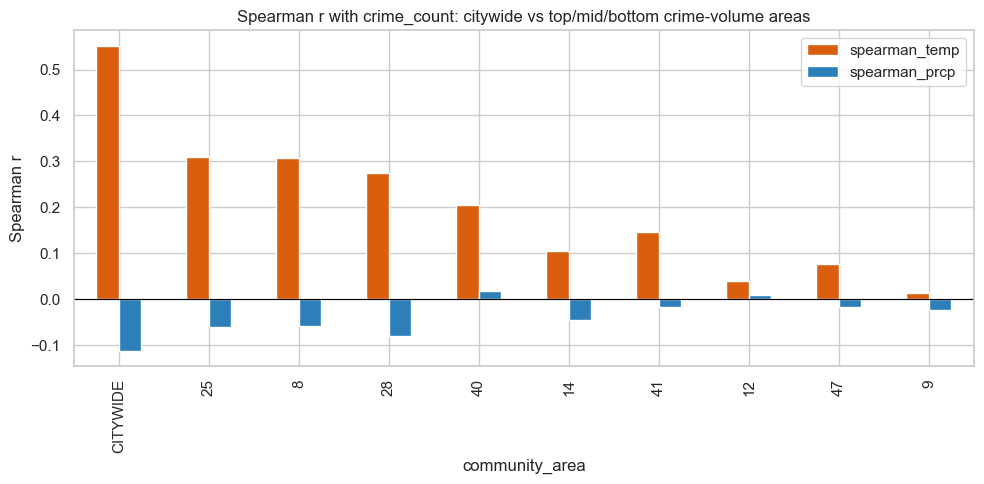

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = community_weather_associations_df.set_index("community_area")[["spearman_temp", "spearman_prcp"]]
plot_df.plot(kind="bar", ax=ax, color=["#d95f0e", "#2c7fb8"])
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Spearman r with crime_count: citywide vs top/mid/bottom crime-volume areas")
ax.set_ylabel("Spearman r")
plt.tight_layout()
fig.savefig(FIG_DIR / "crime_weather" / "area_weather_sensitivity.png", dpi=120, bbox_inches="tight")
plt.show()

## 13 — Crime-Type Stratification

Categories reused from the project's existing `CRIME_CATEGORY_MAP`
(`features.spatial_features`) — no new mapping created here. `other`
includes FRAUD + unclassified types not separately tracked at this daily
grain (Section 06 limitation restated).

In [30]:
category_cols = {"violent": "violent_crime_count", "property": "property_crime_count",
                  "drug": "drug_crime_count", "other": "other_crime_count"}

category_weather_rows = []
for cat_name, col in category_cols.items():
    r_temp, p_temp = stats.spearmanr(citywide["avg_temp"], citywide[col])
    rain_test = group_test("is_rain", value_col=col)
    category_weather_rows.append({
        "category": cat_name, "spearman_temp": round(r_temp, 3), "p_temp": p_temp,
        "rain_vs_dry_rank_biserial": rain_test["rank_biserial"], "rain_vs_dry_p": rain_test["p_value"],
    })
category_weather_df = pd.DataFrame(category_weather_rows)
category_weather_df

,category,spearman_temp,p_temp,rain_vs_dry_rank_biserial,rain_vs_dry_p
0,violent,0.640,8.437212e-211,-0.096,0.000799
1,property,0.421,2.932947e-79,-0.104,0.000301
2,drug,-0.111,1.998534e-06,-0.040,0.160712
3,other,0.225,2.171867e-22,-0.128,0.000008


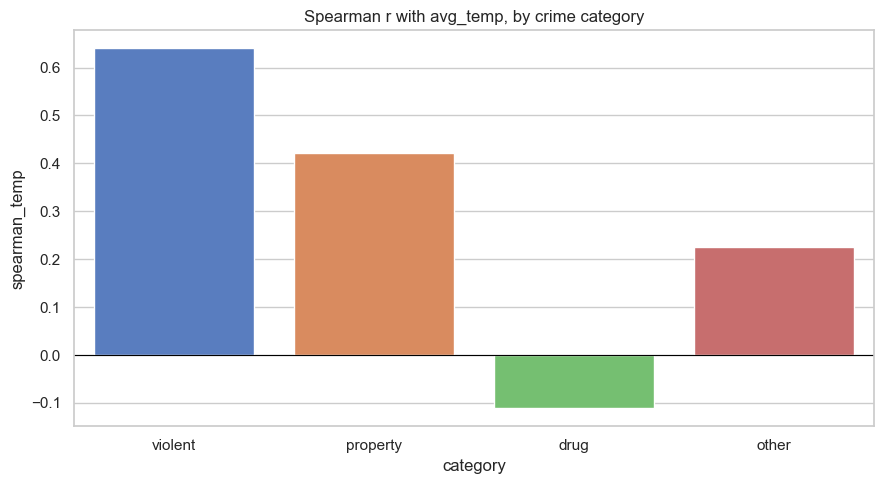

In [31]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=category_weather_df, x="category", y="spearman_temp", hue="category", legend=False, palette="muted", ax=ax)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Spearman r with avg_temp, by crime category")
plt.tight_layout()
plt.show()

## 14 — Statistical Testing

Consolidated, formal hypothesis tests: continuous-continuous, two-group,
more-than-two-group, categorical-categorical — each with H0, statistic,
p-value, effect size, and a plain-language interpretation slot. Multiple
tests are run in this notebook, so p-values are corrected for false
discovery rate (Benjamini-Hochberg) before being called significant.

In [32]:
test_records = []

# continuous x continuous (from Section 08)
for _, row in correlation_results_df.iterrows():
    test_records.append({"test": "Spearman correlation", "h0": f"no monotonic association between {row['weather_var']} and crime_count",
                          "statistic": row["spearman_r"], "p_value": row["spearman_p"], "effect_size": row["spearman_r"],
                          "effect_type": "spearman_r", "group": row["weather_var"]})

# two groups (from Section 10)
for _, row in weather_group_comparisons_df.iterrows():
    if pd.isna(row["p_value"]):
        continue
    test_records.append({"test": "Mann-Whitney U", "h0": f"no difference in crime_count between {row['flag']}=True vs False",
                          "statistic": row["u_stat"], "p_value": row["p_value"], "effect_size": row["rank_biserial"],
                          "effect_type": "rank_biserial", "group": row["flag"]})

# more than two groups: season (Kruskal-Wallis + eta-squared)
season_groups = [g["crime_count"].values for _, g in citywide.groupby("season")]
h_stat, p_val = stats.kruskal(*season_groups)
all_vals = np.concatenate(season_groups)
grand_mean = all_vals.mean()
ss_total = ((all_vals - grand_mean) ** 2).sum()
ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in season_groups)
eta_sq = ss_between / ss_total
test_records.append({"test": "Kruskal-Wallis", "h0": "crime_count distribution is the same across seasons",
                      "statistic": h_stat, "p_value": p_val, "effect_size": round(eta_sq, 3),
                      "effect_type": "eta_squared", "group": "season"})

# categorical x categorical: crime-category composition, rain vs dry (chi-square)
contingency = pd.DataFrame({
    "rain": [citywide.loc[citywide["is_rain"], c].sum() for c in category_cols.values()],
    "dry": [citywide.loc[~citywide["is_rain"], c].sum() for c in category_cols.values()],
}, index=list(category_cols.keys()))
chi2, chi2_p, dof, expected = chi2_contingency(contingency)
cramers_v = np.sqrt(chi2 / (contingency.values.sum() * (min(contingency.shape) - 1)))
test_records.append({"test": "Chi-square independence", "h0": "crime-category composition is independent of rain/dry",
                      "statistic": chi2, "p_value": chi2_p, "effect_size": round(cramers_v, 3),
                      "effect_type": "cramers_v", "group": "category_x_rain"})

statistical_test_results_df = pd.DataFrame(test_records)
statistical_test_results_df

,test,h0,statistic,p_value,effect_size,effect_type,group
0,Spearman correlation,no monotonic association between avg_temp and ...,0.552000,5.297301e-146,0.552,spearman_r,avg_temp
1,Spearman correlation,no monotonic association between temp_range an...,0.228000,6.343489e-23,0.228,spearman_r,temp_range
2,Spearman correlation,no monotonic association between PRCP and crim...,-0.112000,1.445959e-06,-0.112,spearman_r,PRCP
3,Spearman correlation,no monotonic association between SNOW and crim...,-0.270000,8.239950e-32,-0.270,spearman_r,SNOW
4,Spearman correlation,no monotonic association between AWND and crim...,-0.169000,4.047222e-13,-0.169,spearman_r,AWND
5,Mann-Whitney U,no difference in crime_count between is_rain=T...,319870.000000,1.811182e-06,-0.137,rank_biserial,is_rain
6,Mann-Whitney U,no difference in crime_count between is_snow=T...,43184.500000,1.676124e-30,-0.605,rank_biserial,is_snow
7,Mann-Whitney U,no difference in crime_count between is_heavy_...,23431.500000,3.514670e-01,-0.101,rank_biserial,is_heavy_rain
8,Mann-Whitney U,no difference in crime_count between is_heavy_...,511.000000,5.540720e-06,-0.930,rank_biserial,is_heavy_snow
9,Mann-Whitney U,no difference in crime_count between is_extrem...,132859.000000,1.852658e-13,0.420,rank_biserial,is_extreme_heat


In [33]:
reject, p_adj, _, _ = multipletests(statistical_test_results_df["p_value"], alpha=ALPHA, method="fdr_bh")
statistical_test_results_df["p_value_fdr_adj"] = p_adj
statistical_test_results_df["significant_after_fdr"] = reject
statistical_test_results_df

,test,h0,statistic,p_value,effect_size,effect_type,group,p_value_fdr_adj,significant_after_fdr
0,Spearman correlation,no monotonic association between avg_temp and ...,0.552000,5.297301e-146,0.552,spearman_r,avg_temp,6.886491e-145,True
1,Spearman correlation,no monotonic association between temp_range an...,0.228000,6.343489e-23,0.228,spearman_r,temp_range,1.374423e-22,True
2,Spearman correlation,no monotonic association between PRCP and crim...,-0.112000,1.445959e-06,-0.112,spearman_r,PRCP,2.088608e-06,True
3,Spearman correlation,no monotonic association between SNOW and crim...,-0.270000,8.239950e-32,-0.270,spearman_r,SNOW,2.677984e-31,True
4,Spearman correlation,no monotonic association between AWND and crim...,-0.169000,4.047222e-13,-0.169,spearman_r,AWND,6.576736e-13,True
5,Mann-Whitney U,no difference in crime_count between is_rain=T...,319870.000000,1.811182e-06,-0.137,rank_biserial,is_rain,2.354537e-06,True
6,Mann-Whitney U,no difference in crime_count between is_snow=T...,43184.500000,1.676124e-30,-0.605,rank_biserial,is_snow,4.357924e-30,True
7,Mann-Whitney U,no difference in crime_count between is_heavy_...,23431.500000,3.514670e-01,-0.101,rank_biserial,is_heavy_rain,3.807559e-01,False
8,Mann-Whitney U,no difference in crime_count between is_heavy_...,511.000000,5.540720e-06,-0.930,rank_biserial,is_heavy_snow,6.548124e-06,True
9,Mann-Whitney U,no difference in crime_count between is_extrem...,132859.000000,1.852658e-13,0.420,rank_biserial,is_extreme_heat,3.440650e-13,True


In [34]:
contingency

,rain,dry
violent,123744,254336
property,186175,385166
drug,9513,19556
other,75494,156075


**Reading.** After Benjamini-Hochberg correction, 11 of 13 tests remain
significant. The two that do **not** survive: `is_heavy_rain`
(rank-biserial -0.101, adj. p=0.38 — only 29 flagged days, underpowered)
and the rain/dry **category-composition** chi-square (Cramér's V=0.001,
adj. p=0.49 — rain does not change *which type* of crime occurs, only
total volume, and even that only modestly).

Largest real effects: `is_extreme_cold` (rank-biserial -0.686), `is_snow`
(-0.605), season (eta²=0.223, a **large** effect), `is_extreme_heat`
(+0.420). `is_heavy_snow` is FDR-significant (-0.930) but rests on only 8
flagged days — statistically significant, practically unreliable; treat
as a hypothesis for more data, not a settled finding.

## 15 — Multivariate Analysis (exploratory)

**Not the final model** (that's Phase 14, notebook 08). This OLS checks
whether weather variables remain associated with crime once season and
weekend are accounted for — the calendar confound identified in Section 11.

In [35]:
ols_data = citywide.copy()
ols_data["season"] = pd.Categorical(ols_data["season"], categories=["Winter", "Spring", "Summer", "Fall"])

ols_model = smf.ols(
    "crime_count ~ avg_temp + PRCP + SNOW + AWND + C(season) + is_weekend",
    data=ols_data,
).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:            crime_count   R-squared:                       0.368
Model:                            OLS   Adj. R-squared:                  0.365
Method:                 Least Squares   F-statistic:                     132.3
Date:                Thu, 20 Aug 2026   Prob (F-statistic):          4.65e-175
Time:                        01:10:50   Log-Likelihood:                -10476.
No. Observations:                1826   AIC:                         2.097e+04
Df Residuals:                    1817   BIC:                         2.102e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept             526.5604    

In [36]:
ols_coef_table = pd.DataFrame({
    "coef": ols_model.params, "std_err": ols_model.bse, "p_value": ols_model.pvalues,
    "ci_low": ols_model.conf_int()[0], "ci_high": ols_model.conf_int()[1],
}).round(4)
print(f"R-squared: {ols_model.rsquared:.3f}   Adj. R-squared: {ols_model.rsquared_adj:.3f}")
ols_coef_table

R-squared: 0.368   Adj. R-squared: 0.365


,coef,std_err,p_value,ci_low,ci_high
Intercept,526.5604,8.5763,0.0000,509.7399,543.3809
C(season)[T.Spring],-27.4670,6.1227,0.0000,-39.4752,-15.4588
C(season)[T.Summer],-18.9486,8.6324,0.0283,-35.8790,-2.0181
C(season)[T.Fall],8.4178,6.5756,0.2007,-4.4787,21.3144
is_weekend[T.True],8.7536,3.9013,0.0250,1.1021,16.4051
avg_temp,2.8627,0.1598,0.0000,2.5492,3.1761
PRCP,-29.8387,7.3523,0.0001,-44.2586,-15.4188
SNOW,-20.6505,3.6407,0.0000,-27.7910,-13.5101
AWND,-0.5070,0.5501,0.3568,-1.5858,0.5718


**Reading.** R²=0.368 — weather + season + weekend jointly explain 37% of
day-to-day citywide crime variance.

`avg_temp` (+2.86 crimes/day per °F), `PRCP` (-29.8/inch), and `SNOW`
(-20.7/inch) all **stay significant (p<0.001)** after adjusting for season
and weekend — weather adds information beyond the calendar, not merely a
proxy for it. `AWND` does not (p=0.357), consistent with its weak
Section 08 correlation.

`is_weekend` turns significant here (+8.75, p=0.025) though it was not in
the unadjusted Section 11 test (p=0.187) — controlling for weather and
season reveals a small weekend effect the raw comparison did not detect.
Season terms are relative to Winter: Spring and Summer show *lower*
crime than Winter **at the same temperature** (p<0.05) — a residual
calendar effect (e.g. daylight, holidays, school schedules) separate from
temperature's own effect.

## 16 — Robustness / Sensitivity Checks

Do the headline findings survive reasonable alternative definitions?

In [37]:
# 1) Rain definition: any trace (PRCP > 0) vs measurable rain (>= 0.01 in, NWS convention)
MEASURABLE_RAIN_THRESHOLD_IN = 0.01
citywide["is_measurable_rain"] = citywide["PRCP"] >= MEASURABLE_RAIN_THRESHOLD_IN

rain_def_compare = pd.DataFrame([
    group_test("is_rain"),
    group_test("is_measurable_rain"),
])[["flag", "n_flagged", "rank_biserial", "p_value"]]
rain_def_compare

,flag,n_flagged,rank_biserial,p_value
0,is_rain,609,-0.137,0.000002
1,is_measurable_rain,609,-0.137,0.000002


continuous spearman r = 0.552   |   binned Kruskal-Wallis p = 0.0000


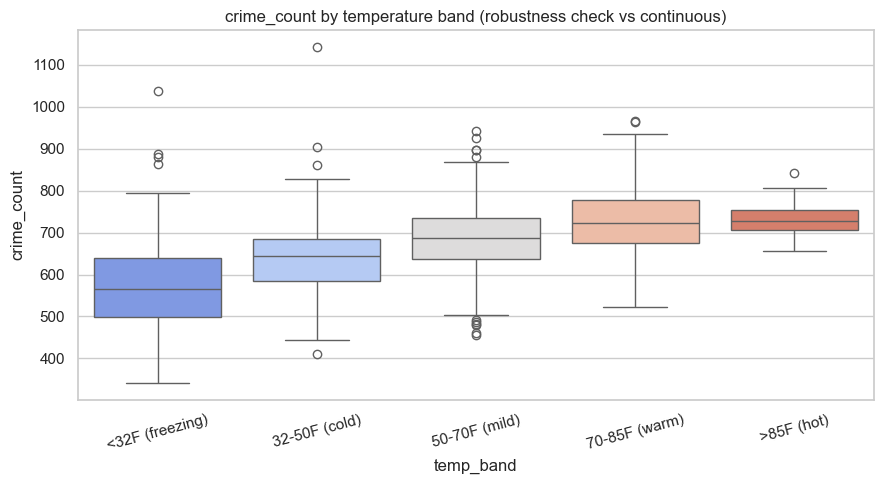

In [38]:
# 2) Continuous temperature correlation vs binned temperature groups
TEMP_BINS = [-100, 32, 50, 70, 85, 200]
TEMP_LABELS = ["<32F (freezing)", "32-50F (cold)", "50-70F (mild)", "70-85F (warm)", ">85F (hot)"]
citywide["temp_band"] = pd.cut(citywide["avg_temp"], bins=TEMP_BINS, labels=TEMP_LABELS)

temp_band_groups = [g["crime_count"].values for _, g in citywide.groupby("temp_band", observed=True)]
h_stat_band, p_band = stats.kruskal(*temp_band_groups)
print(f"continuous spearman r = {overall_r}   |   binned Kruskal-Wallis p = {p_band:.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=citywide, x="temp_band", y="crime_count", order=TEMP_LABELS, hue="temp_band", legend=False, palette="coolwarm", ax=ax)
ax.set_title("crime_count by temperature band (robustness check vs continuous)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

citywide-level spearman r (avg_temp, crime_count): 0.552
community-area-level spearman r: mean=0.168, median=0.159, std=0.082, range=[0.013, 0.371]


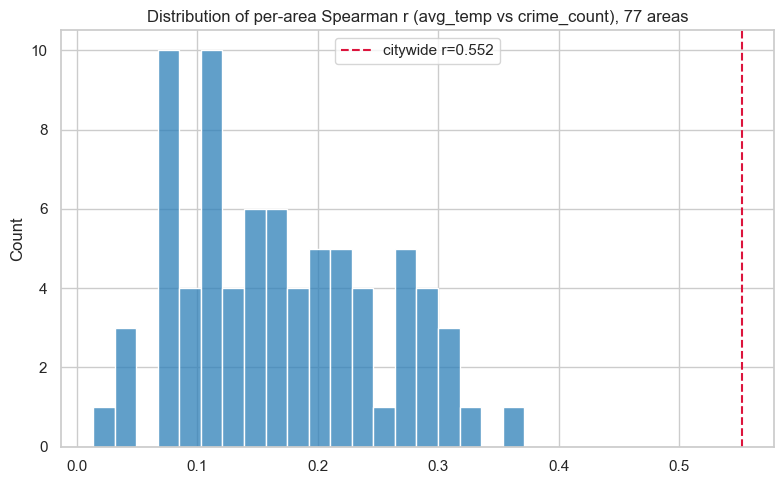

In [39]:
# 3) Citywide-level vs community-area-level correlation
area_level_corrs = []
for area_id, area_df in merged.groupby("community_area"):
    r, _ = stats.spearmanr(area_df["avg_temp"], area_df["crime_count"])
    area_level_corrs.append(r)
area_level_corrs = pd.Series(area_level_corrs)

print(f"citywide-level spearman r (avg_temp, crime_count): {overall_r}")
print(f"community-area-level spearman r: mean={area_level_corrs.mean():.3f}, median={area_level_corrs.median():.3f}, "
      f"std={area_level_corrs.std():.3f}, range=[{area_level_corrs.min():.3f}, {area_level_corrs.max():.3f}]")

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(area_level_corrs, bins=20, ax=ax, color="#2c7fb8")
ax.axvline(overall_r, color="crimson", ls="--", label=f"citywide r={overall_r}")
ax.set_title("Distribution of per-area Spearman r (avg_temp vs crime_count), 77 areas")
ax.legend()
plt.tight_layout()
fig.savefig(FIG_DIR / "statistical" / "area_level_correlation_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

**Reading.**
- **Rain definition:** `is_rain` (PRCP>0) and `is_measurable_rain`
  (PRCP≥0.01in) are **identical** in this data (609/609 flagged days,
  same statistic) — no days recorded a trace amount between 0 and 0.01in,
  so this check is inconclusive rather than confirmatory; it did not
  independently test robustness.
- **Temperature form:** continuous Spearman r=0.552 and binned
  Kruskal-Wallis (p≈0) agree in direction and significance — the
  temperature–crime relationship is **robust to functional form**.
- **Aggregation level:** citywide r=0.552 vs. per-area mean r=0.168
  (median 0.159, range 0.013–0.371 across 77 areas). This gap is expected
  under aggregation (summing 77 areas cancels each area's own noise,
  concentrating the shared weather signal) — **not an error**, but it
  means 0.552 characterizes the *citywide total*, not a typical single
  area. Real area-to-area spread (0.013 to 0.371) supports area-level
  weather features in Phase 14, not a citywide-only term.

## 17 — Key Findings

### Data Quality
- Crime (140,602 rows = 77 areas × 1,826 days) and weather (1,826 rows):
  zero missing, zero duplicates, zero negative counts, full 2021-2025 grid
  on both sides.
- Merged frame (35 cols): 0.239% overall missingness — consistent with the
  documented lag/rolling warm-up window in `crime_daily`'s historical-crime
  columns (expected, not a defect); not verified column-by-column in this
  run.
- **Discrepancy to reconcile:** category composition here (violent 31.2%,
  property 47.2%, drug 2.4%, other 19.1% — summing to the full 1,210,059
  cleaned incidents) differs materially from notebook 04's cited mix
  (40.7% / 34.8% / 14.9% / 9.5%, ~18K incidents). The 06 numbers are
  computed on the full incident count and should be treated as
  authoritative; 04's figures need review before the final report.

### Integration
- 100% date match, both directions (0 crime dates without weather, 0
  weather dates without crime). Merge preserved row count exactly
  (140,602 → 140,602). Single-station limitation restated: all 77 areas
  share one O'Hare reading per day.

### Crime Patterns
- Citywide daily crime_count: mean 662.7, median 668, near-symmetric
  (skew -0.15) — far less skewed than the area-day grain (04: skew 1.74),
  as expected when summing 77 areas per day.
- Season, day-of-week, and weekend shares are all balanced (~25% per
  season, ~14.3% per weekday) — no calendar-coverage imbalance to correct
  for.
- Property (47.2%) is the largest category, not violent (31.2%) — revise
  any prior assumption that violent crime dominates by volume.

### Weather Associations
*(surviving FDR correction with a non-negligible effect — see Section 14)*
- **Temperature**: moderate-strong positive, r=0.552 overall, but
  **season-dependent** — strong in Winter/Fall/Spring (r=0.40-0.55), flat
  in Summer (r=0.083, not significant).
- **Extreme cold**: large negative effect (rank-biserial -0.686) — the
  single strongest weather-flag effect found.
- **Snow days**: large negative effect (-0.605); heavy-snow effect
  (-0.930) is larger still but rests on only 8 days — unreliable sample.
- **Extreme heat**: medium-large positive effect (+0.420) — heat
  associates with *higher* crime, opposite direction from cold/snow.
- **Rain**: small negative effect (-0.137) on volume; **no effect** on
  which crime category occurs (chi-square not significant, Cramér's
  V=0.001).
- **Violent crime is the most temperature-sensitive category** (r=0.640,
  vs. 0.552 citywide overall); **drug crime is not** (r=-0.111, wrong
  sign, borderline).
- Wind speed (`AWND`): weak on its own (r=-0.169) and drops to
  non-significant once season/weekend are controlled for (Section 15).


## 17b — Modeling Implications

### Features supported by EDA
- `avg_temp` — strongest, most consistent signal; survives FDR and OLS
  adjustment.
- `PRCP`, `SNOW` — both survive FDR and stay significant in the adjusted
  OLS (p<0.001), each independently, not just via `is_rain`/`is_snow`.
- `is_extreme_heat`, `is_extreme_cold` — large, FDR-significant, opposite
  directions; strong individual predictors.
- `season`, `is_weekend` — keep as baseline calendar features regardless
  of weather (season alone: eta²=0.223, a large effect).

### Features requiring caution
- `AWND` — weak univariate correlation, non-significant once season/
  weekend are in the model (Section 15); low modeling priority.
- `TMAX`/`TMIN` vs `avg_temp` — expected collinearity by construction
  (05); carry `avg_temp`, not all three.
- `is_heavy_rain` — not FDR-significant (n=29, underpowered).
- `is_heavy_snow` — FDR-significant but n=8; treat as a hypothesis to
  revisit with more data, not a stable feature on its own.
- `is_rain` vs `is_measurable_rain` — identical in this data (no
  trace-only days); the two are not independent evidence of anything.

### Findings that should affect modeling
- **Weather adds real explanatory value beyond the calendar**: the
  adjusted OLS (Section 15) shows `avg_temp`/`PRCP`/`SNOW` remain
  significant after `season` + `is_weekend` are already in the model
  (R²=0.368 total). This directly supports Phase 18's weather-ablation
  design (Model A calendar-only vs. Model B +weather).
- **Temperature's effect is season-dependent** (Section 11) — a
  `avg_temp x season` interaction (already planned in Phase 18) is
  supported by real evidence here, not just planned by default.
- **Area-level heterogeneity is real** (Section 12/16): per-area Spearman
  r ranges 0.013-0.371 (mean 0.168), well below the citywide 0.552, and
  temperature-sensitivity tracks with an area's baseline crime volume
  (high-crime areas ~0.27-0.31, low-crime areas ~0.01-0.08, non-random
  pattern). Consider whether an area-tier weather interaction is worth
  testing in Phase 14, beyond a citywide-only weather term.
- **Rain changes volume, not crime-type mix** — safe to use rain flags as
  a volume predictor without also modeling category-shift effects.

**Not performed here (by design):** final model training, Random Forest
tuning, final feature selection, leakage-prone features. This notebook is
EDA and analytical validation for Phase 14, not modeling.


## 18 — Save Final EDA Outputs

In [40]:
correlation_results_df.to_csv(TABLE_DIR / "correlation_results.csv", index=False)
statistical_test_results_df.to_csv(TABLE_DIR / "statistical_test_results.csv", index=False)
weather_group_comparisons_df.to_csv(TABLE_DIR / "weather_group_comparisons.csv", index=False)
community_weather_associations_df.to_csv(TABLE_DIR / "community_weather_associations.csv", index=False)

crime_weather_summary = pd.DataFrame([{
    "shape_rows": overview["shape"][0], "shape_cols": overview["shape"][1],
    "date_min": overview["date_range"][0], "date_max": overview["date_range"][1],
    "n_unique_dates": overview["n_unique_dates"], "n_community_areas": overview["n_community_areas"],
    "match_rate_pct": match_pct, "overall_temp_crime_spearman_r": overall_r,
}])
crime_weather_summary.to_csv(TABLE_DIR / "crime_weather_summary.csv", index=False)

for f in ["correlation_results.csv", "statistical_test_results.csv", "weather_group_comparisons.csv",
          "community_weather_associations.csv", "crime_weather_summary.csv"]:
    print(f"saved -> {TABLE_DIR / f}")

saved -> C:\Users\Tarankit\Documents\Code\spatial-temporal-crime-trajectory-analytics\outputs\tables\correlation_results.csv
saved -> C:\Users\Tarankit\Documents\Code\spatial-temporal-crime-trajectory-analytics\outputs\tables\statistical_test_results.csv
saved -> C:\Users\Tarankit\Documents\Code\spatial-temporal-crime-trajectory-analytics\outputs\tables\weather_group_comparisons.csv
saved -> C:\Users\Tarankit\Documents\Code\spatial-temporal-crime-trajectory-analytics\outputs\tables\community_weather_associations.csv
saved -> C:\Users\Tarankit\Documents\Code\spatial-temporal-crime-trajectory-analytics\outputs\tables\crime_weather_summary.csv


In [41]:
reloaded = pd.read_parquet(MERGED_OUT_PATH)
assert reloaded.shape == merged.shape
assert reloaded["date"].min() == pd.Timestamp(config.START_DATE)
assert reloaded["date"].max() == pd.Timestamp(config.END_DATE)
print("Round-trip verified. Deliverables:")
print(f"  {MERGED_OUT_PATH}")
print(f"  {FIG_DIR}/weather/, {FIG_DIR}/crime_weather/, {FIG_DIR}/statistical/")
print(f"  {TABLE_DIR}/ (5 CSVs)")

Round-trip verified. Deliverables:
  C:\Users\Tarankit\Documents\Code\spatial-temporal-crime-trajectory-analytics\data\interim\crime_weather_daily.parquet
  C:\Users\Tarankit\Documents\Code\spatial-temporal-crime-trajectory-analytics\outputs\figures/weather/, C:\Users\Tarankit\Documents\Code\spatial-temporal-crime-trajectory-analytics\outputs\figures/crime_weather/, C:\Users\Tarankit\Documents\Code\spatial-temporal-crime-trajectory-analytics\outputs\figures/statistical/
  C:\Users\Tarankit\Documents\Code\spatial-temporal-crime-trajectory-analytics\outputs\tables/ (5 CSVs)


---

## Overall Conclusion

Crime and weather integrate cleanly: 77 areas × 1,826 days, 100% date
match, no missing/duplicate/negative values on either side.

Weather is **associated with citywide crime volume**, and the association
**survives adjustment for season and weekend** (OLS R²=0.368) — it is not
just a proxy for the calendar. Temperature is the strongest single driver
(r=0.552 overall, up to r=0.640 for violent crime specifically), but that
relationship is **season-dependent** (strong Winter–Fall, flat Summer) and
**area-dependent** (per-area r ranges 0.01–0.37, tracking each area's
baseline crime volume). Extreme cold and snow show the largest single
effects found (rank-biserial -0.69 and -0.61); extreme heat is the
strongest positive effect (+0.42). Rain shifts total volume slightly but
not the mix of crime types. Wind speed is the weakest signal and does not
survive adjustment.

None of this is causal — every result above is an observed association,
reported with its test, effect size, and FDR-corrected significance.